# Esperimenti Lora

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import ast

In [2]:
RESULT_TOT="../data/training_dataset/results/results_combined.csv"
RESULT = "../data/training_dataset/results/test_qwen-chat-agent-12-step-51_2026_03_27.csv" 
models = ['chat-qwen','chat-qwen-tuned-qlora-16-v4', 'extractor-qwen-tuned-qlora-16-v2', 'extractor-qwen-tuned-qlora-16-v3']
colors = cm.tab10.colors
df = pd.read_csv(RESULT_TOT)
df_add = pd.read_csv(RESULT)

In [3]:
df.columns

Index(['model', 'language', 'messaggi', 'ore_ordinarie_true',
       'ore_straordinarie_true', 'ore_viaggio_true', 'note_true',
       'inefficiency_true', 'inefficiency_note_true', 'chat_context',
       'function_calls', 'push_data_response', 'ore_ordinarie_acc',
       'ore_straordinarie_acc', 'ore_viaggio_acc', 'inefficiency_acc',
       'tot_acc', 'ore_ordinarie_predict', 'ore_straordinarie_predict',
       'ore_viaggio_predict', 'note_predict', 'inefficiency_predict',
       'inefficiency_note_predict', 'REF_INDICE', 'L_MESSAGGI', 'TYPE_EVAL',
       'count_function_calls', 'failure_reason',
       'sentence_similarity_score_note',
       'sentence_similarity_score_inefficiency'],
      dtype='object')

## Preprocessing dei dati

In [4]:
def func_call(str_list):
    l = ast.literal_eval(str_list)
    return len(l)
    
df_add['count_function_calls'] = df_add['function_calls'].apply(func_call)

df_add['count_function_calls'].unique()

array([1, 3, 2, 4, 5, 0])

In [5]:
""" indetificare quali sono i risultati con errori (escludendo se mancano commenti per ora)
    il caso di errore dipende dalla TYPE_EVAL:
    - flow: 
        - se il numero di count_function_calls non è uguale al numero di messaggi del campione
        - se l'ultima function call non è una push_data con valore True
    - edge_why:
        - se il numero di count_function_calls non è uguale al numero di messaggi del campione
        - se l'ultima function call non è una push_data con valore True     
 """
def func_failure(row):
    len_msg = row['L_MESSAGGI']
    if row['count_function_calls'] != len_msg:
        # controlliamo che l'ultima function call è push_data:
        l = ast.literal_eval(row['function_calls'])
        if l and l[-1] != 'push_data':
            return "Agent don't finish with push_data"
        if row['count_function_calls'] == 0:
             return "model don't call any tool at the start"
        return "function calls disalignment with the messages"
        
    # controlliamo che l'ultima function call è push_data:
    l = ast.literal_eval(row['function_calls'])
    if l[-1] != 'push_data':
        return "Agent don't finish with push_data"
    else:
        match row['push_data_response']:
                case True:
                    return None
                case '1.0': return "push_data_response is a string"
                case 'True': return "push_data_response is a string"
                case 'False': return "Agent put False as params in push_data"
                case _: return "push_data_response is null"

df_add['failure_reason'] = df_add.loc[df['TYPE_EVAL'] != 'edge_random'].apply(func_failure, axis=1)

In [6]:
from tqdm import tqdm
from sentence_transformers import SentenceTransformer, util 
from rouge_score import rouge_scorer

def add_similarity(data:pd.DataFrame, column_name:str,label_column:str, predict_column:str, metric:str)-> pd.DataFrame:
    """Creare una nuova colonna per fare similarità sul testo"""
    indexes = data.loc[data[label_column].isna() != True].index
    metric_model = None
    if metric == 'sentence_similarity':
        metric_model = SentenceTransformer('sentence-transformers/paraphrase-multilingual-mpnet-base-v2')
    else:
        metric_model = rouge_scorer.RougeScorer(['rouge1', 'rouge2', 'rougeL'], use_stemmer=True)
    for idx in tqdm(indexes):
        label = data.at[idx, label_column]
        pred = str(data.at[idx, predict_column])
        
        if pred == 'nan':
            data.loc[idx,column_name] = 0
        else:
            match metric:
                case 'sentence_similarity':
                    emb_l = metric_model.encode(label)
                    try:
                        emb_p = metric_model.encode(pred)
                    except TypeError as e:
                        Exception(f"errore nel fare l'embdedding di {pred}\t {e}")
                    data.loc[idx,column_name] = round(util.cos_sim(emb_l, emb_p).item(),3)
                case 'rouge':
                    scores = metric_model.score(label, pred)
                    data.loc[idx, column_name] = round(scores['rougeL'].fmeasure,3)
    return data

/home/tecnico/SitiBT-Agent-AI/.venv/lib64/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [7]:
df_add = add_similarity(df_add, "sentence_similarity_score_note", "note_true","note_predict","sentence_similarity")

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 995.12it/s, Materializing param=pooler.dense.weight]                               
XLMRobertaModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-mpnet-base-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
100%|██████████| 542/542 [00:25<00:00, 21.66it/s]


In [8]:
df_add = add_similarity(df_add, "sentence_similarity_score_inefficiency", "inefficiency_note_true","inefficiency_note_predict","sentence_similarity")

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 901.16it/s, Materializing param=pooler.dense.weight]                               
XLMRobertaModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-mpnet-base-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
100%|██████████| 36/36 [00:04<00:00,  8.47it/s]


## Merge con dati finali

In [9]:
df = pd.concat([df, df_add], ignore_index=True)

In [10]:
print(df.groupby(['model'])['TYPE_EVAL'].count())
df.groupby(['language','TYPE_EVAL'])['model'].count()

model
chat-qwen-base                               600
chat-qwen-tuned-qlora-16-v4                  600
chat-tuned-qwen-lora-16-v3                   600
extractor-qwen-tuned-qlora-16-v1             600
extractor-qwen-tuned-qlora-16-v2             600
extractor-qwen-tuned-qlora-16-v3             600
qwen-chat-agent-12                           600
qwen-chat-agent-12-step-51                   600
qwen-chat-agent-5                            600
qwen-chat-extractor-tuned-lora-16-v1         600
qwen-chat-tuned-lora-16-rollout-10-v1        600
qwen-chat-tuned-lora-16-rollout-5-v1         600
qwen-chat-tuned-lora-16-wo-embedding-5-v1    600
Name: TYPE_EVAL, dtype: int64


language  TYPE_EVAL          
english   normal                  273
          normal_w_correction     482
italian   edge_no_explain         117
          normal                 4201
          normal_w_correction    1829
spanish   normal                  491
          normal_w_correction     407
Name: model, dtype: int64

In [11]:
# salviamo il df finale
df.to_csv("../data/training_dataset/results/results_combined.csv", index=False, index_label=False)

In [26]:
print(f"passed sample: {df['failure_reason'].isna().sum()}/{len(df)}")
df.groupby(['failure_reason','model'])['REF_INDICE'].count()

passed sample: 4998/6600


failure_reason                                 model                                      
Agent don't finish with push_data              chat-qwen-base                                 187
                                               chat-qwen-tuned-qlora-16-v4                     89
                                               chat-tuned-qwen-lora-16-v3                     132
                                               extractor-qwen-tuned-qlora-16-v1               174
                                               extractor-qwen-tuned-qlora-16-v2               176
                                               extractor-qwen-tuned-qlora-16-v3               169
                                               qwen-chat-extractor-tuned-lora-16-v1            88
                                               qwen-chat-tuned-lora-16-rollout-10-v1          112
                                               qwen-chat-tuned-lora-16-rollout-5-v1            36
                           

## Accuracy tot ore
Anche se questo riguarda più un possibile test sull'extractor



In [11]:
target ='base|chat'
models = list(df[df['model'].str.contains(target)]['model'].unique())
#labels = ['qwen-base','extractor-reward-boolean','extractor-reward-mean-1.5','extractor-reward-mean','extractor-reward-mean-w-embedding-1.5']

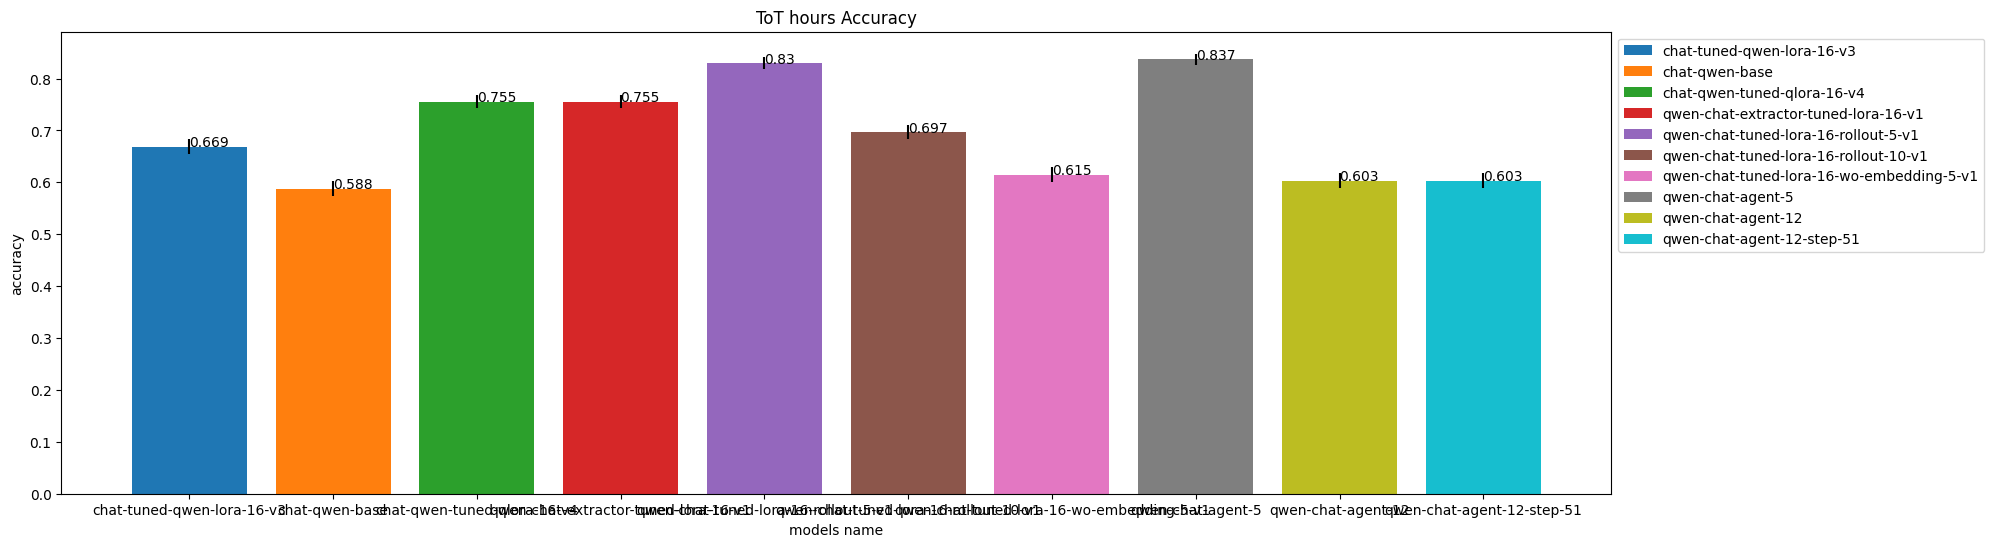

In [12]:
def add_labels(labels, vals):
    for i in range(len(labels)):
        plt.text(i,vals[i], vals[i])

media_group = []
CI_group = []


for model in models:
    acc_media = round(df.loc[(df['model'] == model)  ]['tot_acc'].mean(),3)
    n = len(df)
    # intervallo di confidenza al 99 %
    CI = 2.576 * np.sqrt(acc_media * (1- acc_media) / n)
    media_group.append(acc_media)
    CI_group.append(CI)

plt.figure(figsize=(20,6))
plt.bar(models, media_group, yerr=CI_group, color=colors , label=models)
add_labels(models,media_group)
plt.title("ToT hours Accuracy")
plt.xlabel("models name")
plt.ylabel("accuracy")
plt.legend(loc="upper left", bbox_to_anchor=(1, 1))

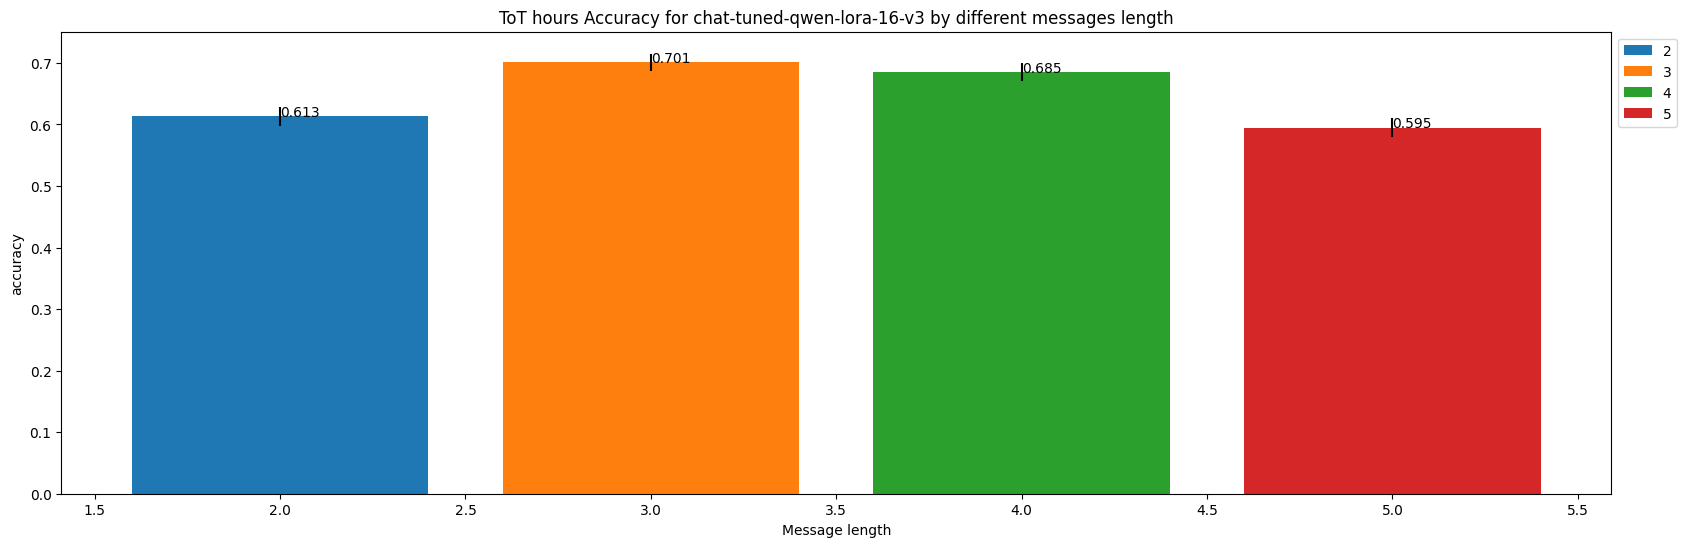

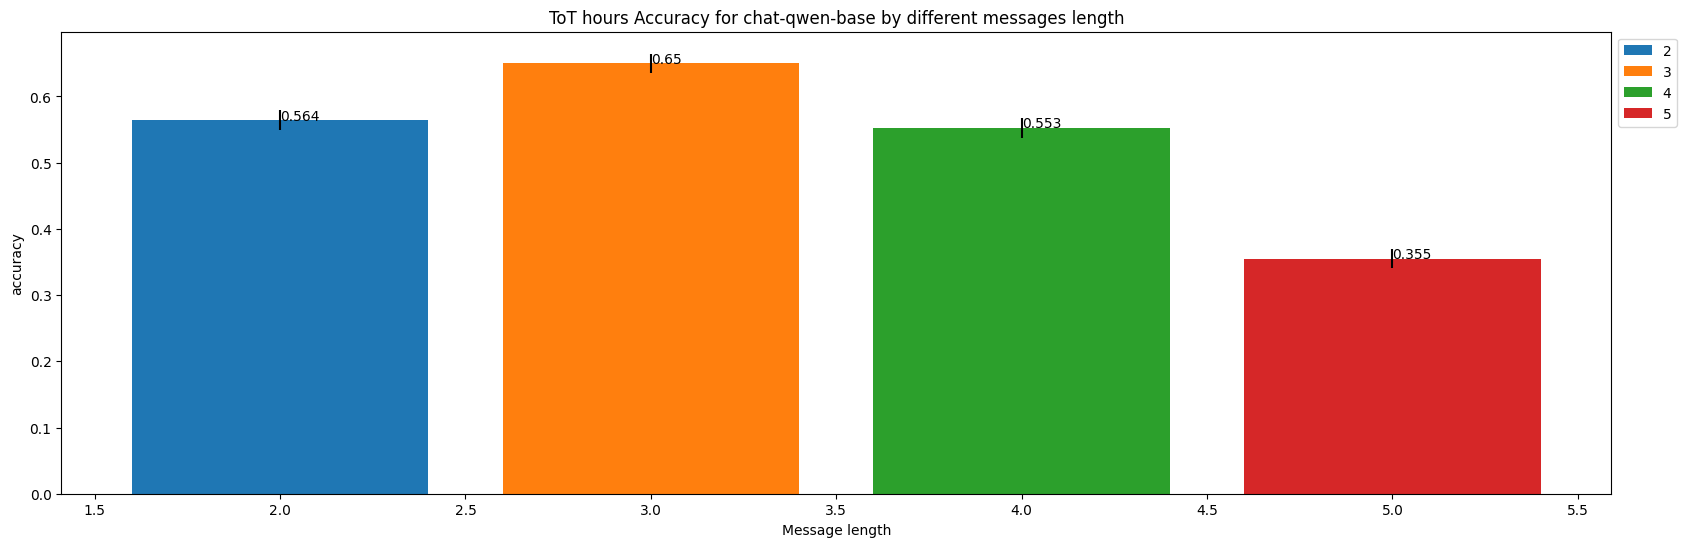

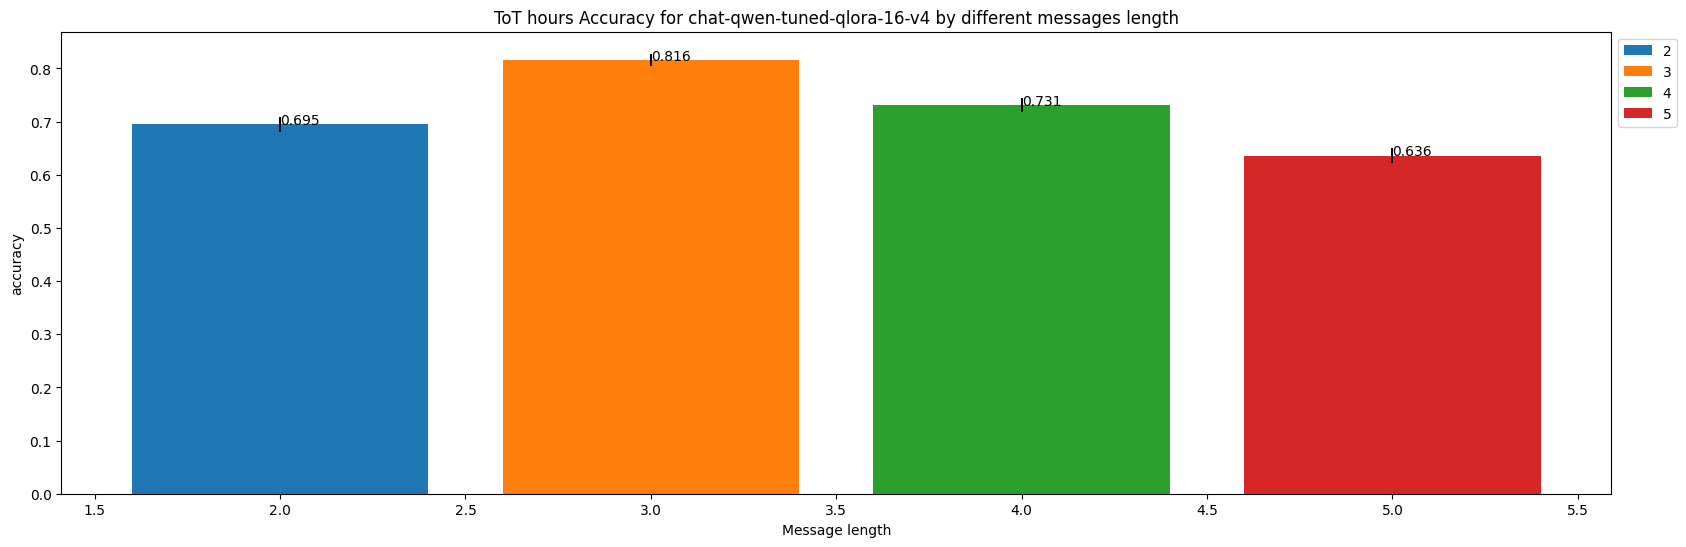

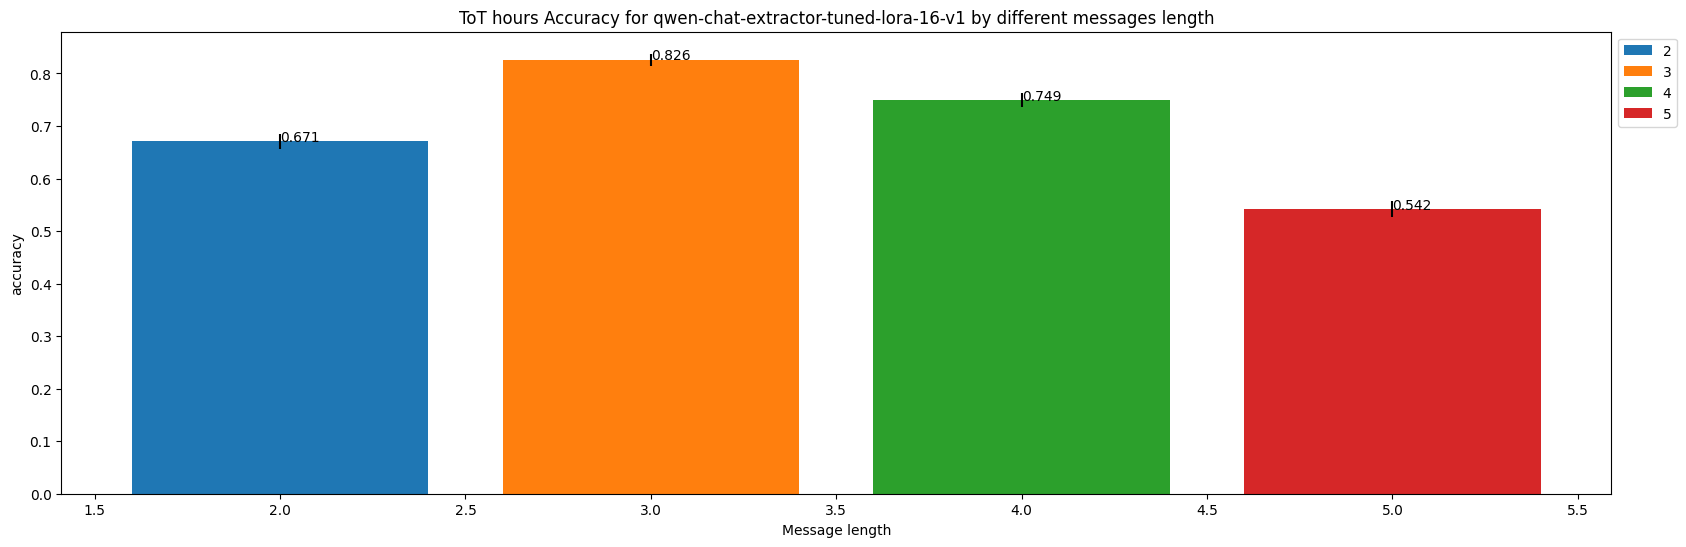

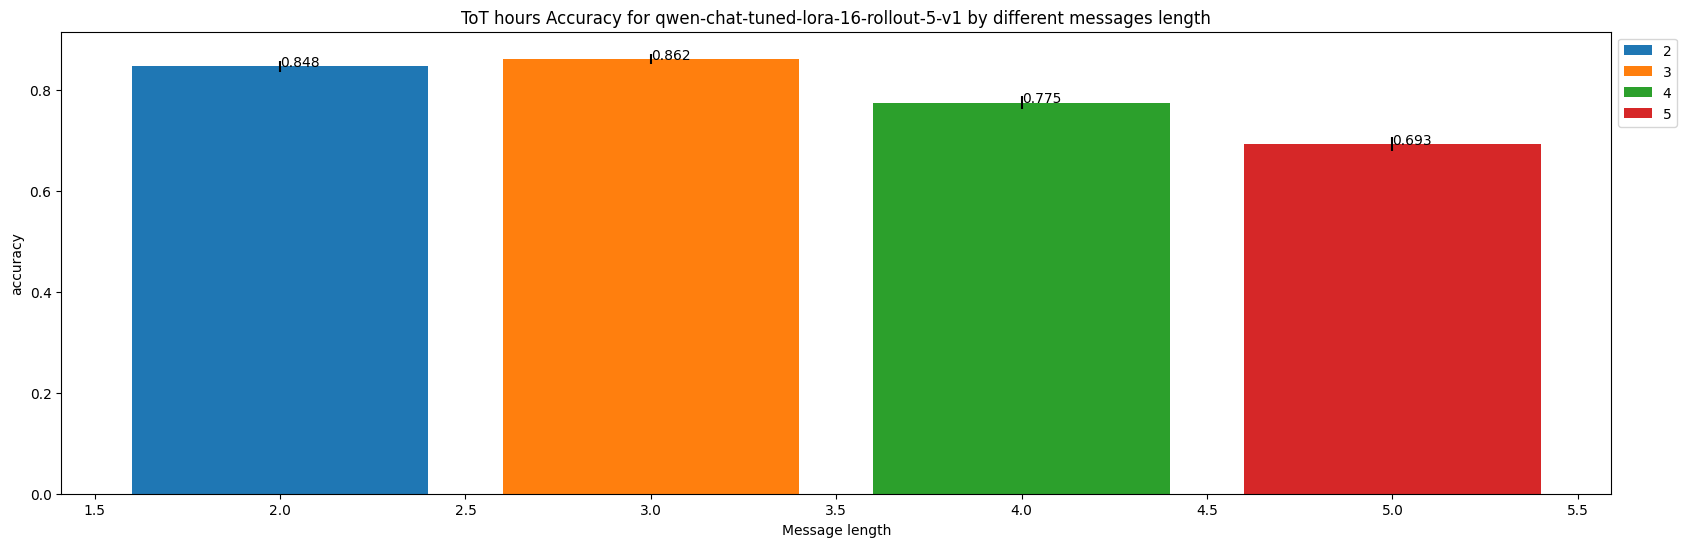

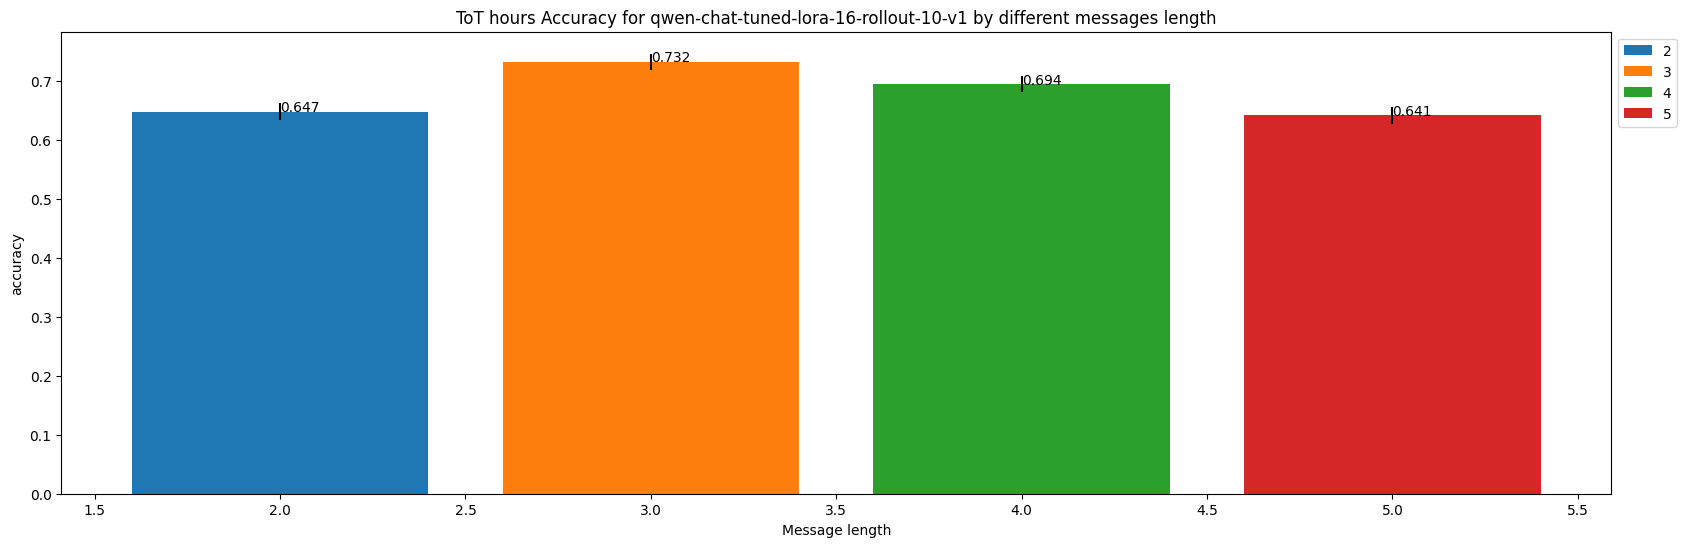

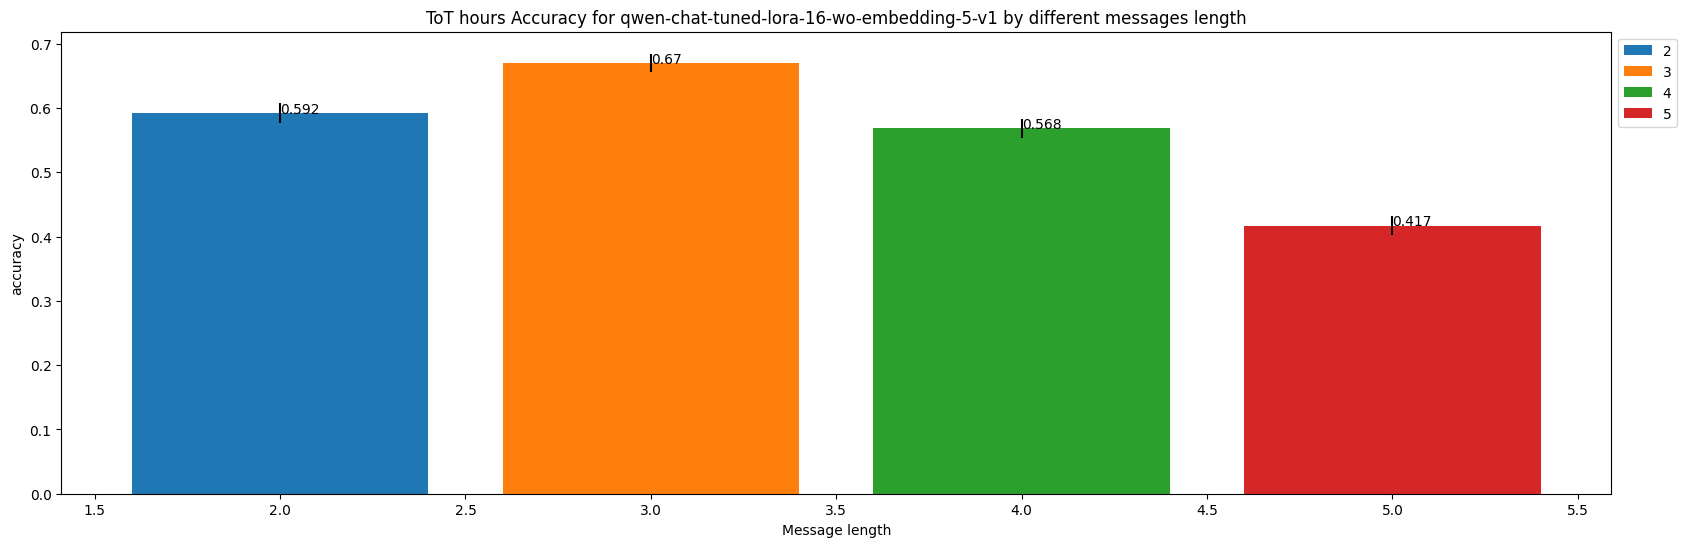

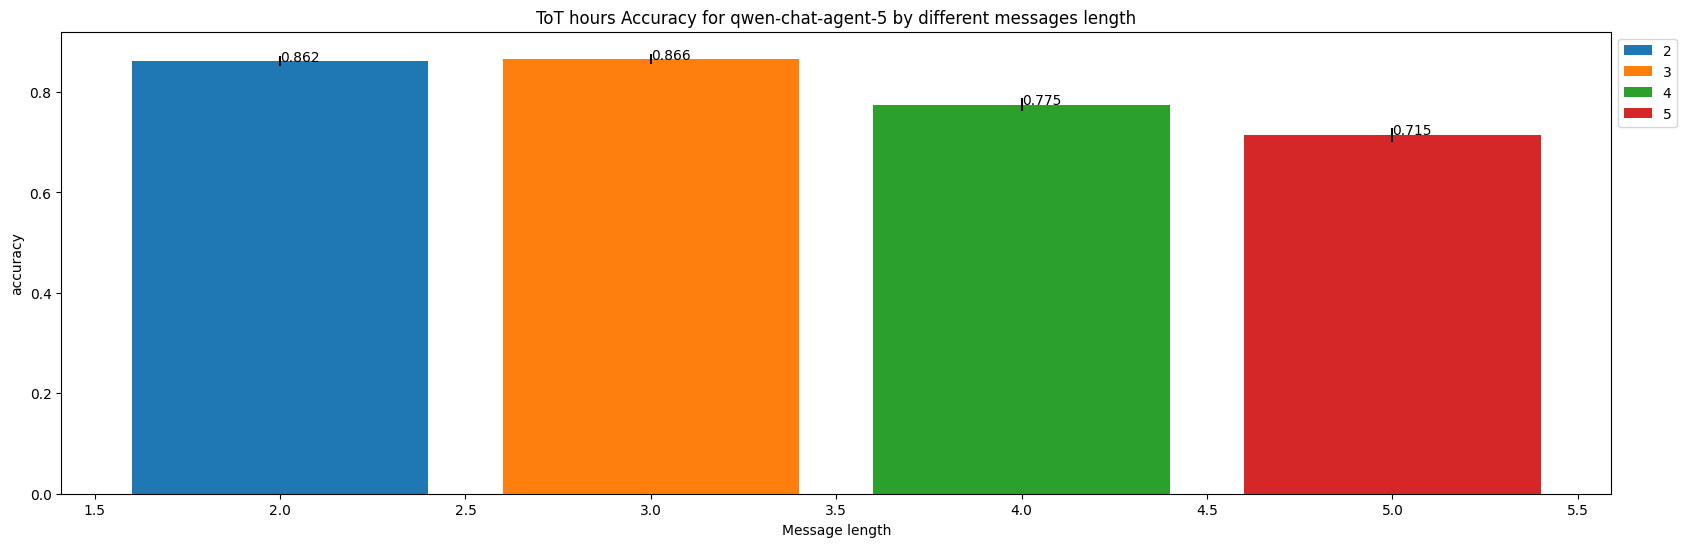

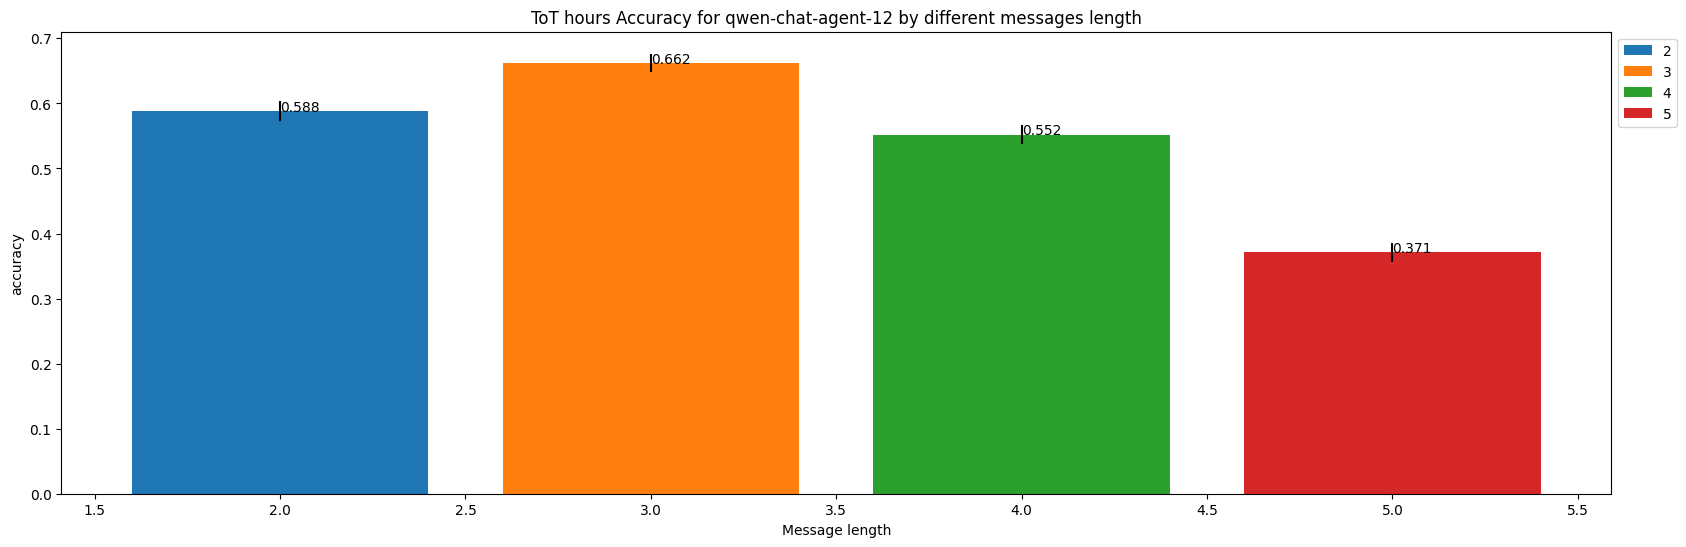

In [14]:
# accuracy a diversi livelli di lunghezza della lista messaggi
def add_labels(labels, vals):
    for i,x_label in enumerate(labels):
        plt.text(x_label,vals[i], vals[i])

models = list(df[df['model'].str.contains(target)]['model'].unique())

for model in models:
    media_group = []
    CI_group = []
    l_msg = np.sort(df['L_MESSAGGI'].unique())
    for length_m in l_msg:
        acc_media = round(df.loc[(df['model'] == model)  & (df['L_MESSAGGI'] == length_m)]['tot_acc'].mean(),3)
        n = len(df)
        # intervallo di confidenza al 99 %
        CI = 2.576 * np.sqrt(acc_media * (1- acc_media) / n)
        media_group.append(acc_media)
        CI_group.append(CI)

    plt.figure(figsize=(20,6))
    plt.bar(l_msg,media_group, yerr=CI_group, color=colors, label=l_msg)
    add_labels(l_msg,media_group)
    plt.title(f"ToT hours Accuracy for {model} by different messages length")
    plt.xlabel("Message length")
    plt.ylabel("accuracy")
    plt.legend(loc="upper left", bbox_to_anchor=(1, 1))

## Accurratezza dei campi note e  inefficienza


In [15]:
# cosine similarity del campo note con Sentence similarity
def add_labels(labels, vals):
    for i in range(len(labels)):
        plt.text(i,vals[i], vals[i])
media_group = []
CI_group = []
models = list(df[df['model'].str.contains(target)]['model'].unique())
for model in models:
    acc_media = round(df.loc[(df['model'] == model)  & (df['sentence_similarity_score_note'].isna() != True)]['sentence_similarity_score_note'].mean(),3)
    n = len(df)
    # intervallo di confidenza al 99 %
    CI = 2.576 * np.sqrt(acc_media * (1- acc_media) / n)
    media_group.append(acc_media)
    CI_group.append(CI)

plt.figure(figsize=(20,6))
plt.bar(labels, media_group, yerr=CI_group, color=colors, label=labels)
add_labels(models,media_group)
plt.title("Cosine Sentence Similarity for label 'note'")
plt.xlabel("models name")
plt.ylabel("Similarity")
plt.legend(loc="upper left", bbox_to_anchor=(1, 1))

NameError: name 'labels' is not defined

<Figure size 2000x600 with 0 Axes>

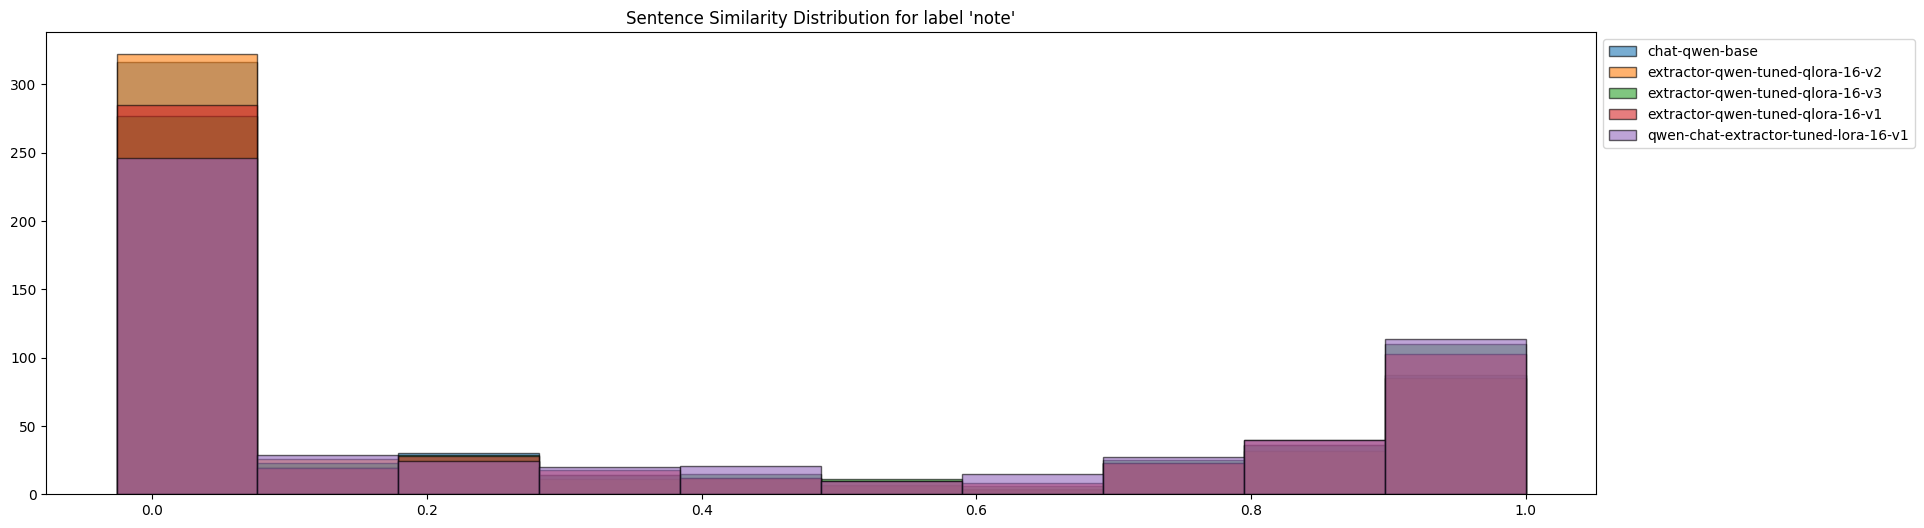

In [16]:
# distribuzione cosine similarity per il campo note
plt.figure(figsize=(20,6))
all_data = []
for model in models:
    data = df.loc[(df['model'] == model) & 
                  (df['sentence_similarity_score_note'].isna() != True)]['sentence_similarity_score_note']
    all_data.append(data)

min_val = min([d.min() for d in all_data])
max_val = max([d.max() for d in all_data])
bins = np.linspace(min_val, max_val, 11) ## 11 val -> 10 bin
for i, model in enumerate(models):
    plt.hist(all_data[i],
             bins=bins,  # Usa i bin espliciti invece di solo il numero
             histtype="bar",  # Cambiato da "barstacked"
             facecolor=colors[i],
             alpha=0.6,  # Aggiungi trasparenza per vedere sovrapposizioni
             label=model,
             edgecolor='black')
plt.title("Sentence Similarity Distribution for label 'note'")
plt.legend(loc="upper left", bbox_to_anchor=(1, 1))

### note inefficienza

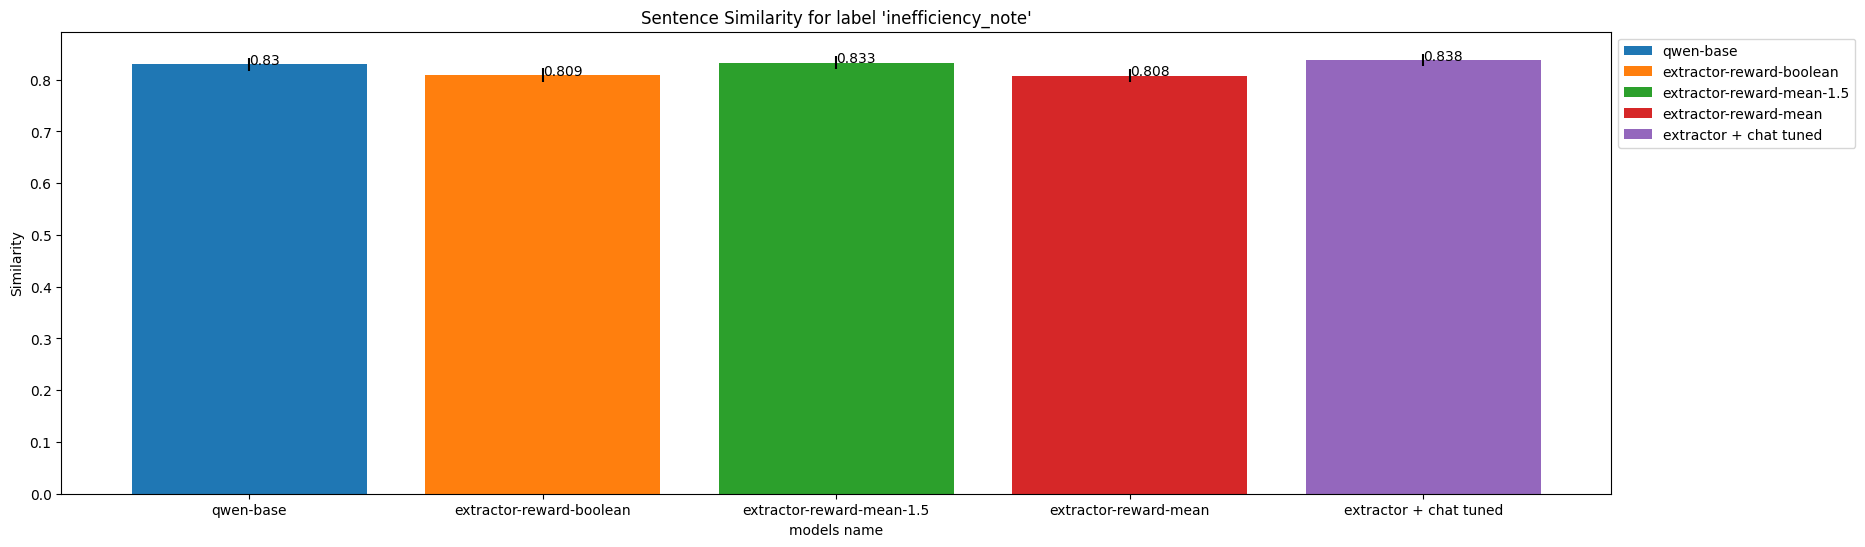

In [17]:
# cosine similarity campo inefficiency desciption
def add_labels(labels, vals):
    for i in range(len(labels)):
        plt.text(i,vals[i], vals[i])
media_group = []
CI_group = []
for model in models:
    acc_media = round(df.loc[(df['model'] == model) & (df['sentence_similarity_score_inefficiency'].isna() != True)]['sentence_similarity_score_inefficiency'].mean(),3)
    n = len(df)
    # intervallo di confidenza al 99 %
    CI = 2.576 * np.sqrt(acc_media * (1- acc_media) / n)
    media_group.append(acc_media)
    CI_group.append(CI)

plt.figure(figsize=(20,6))
plt.bar(labels, media_group, yerr=CI_group, color=colors, label=labels)
add_labels(models,media_group)
plt.title("Sentence Similarity for label 'inefficiency_note'")
plt.xlabel("models name")
plt.ylabel("Similarity")
plt.legend(loc="upper left", bbox_to_anchor=(1, 1))

## Final Accuracy Recap

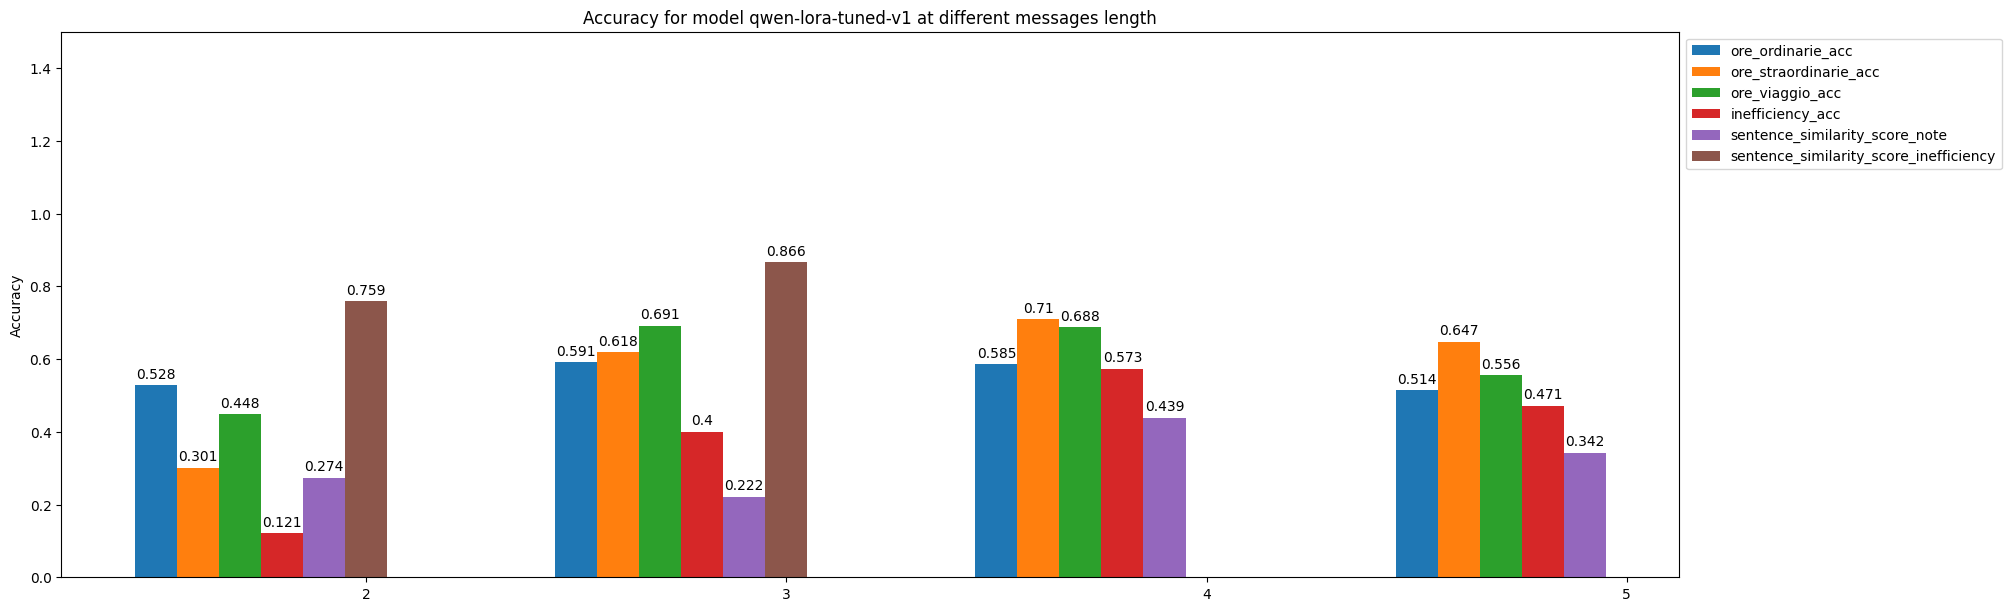

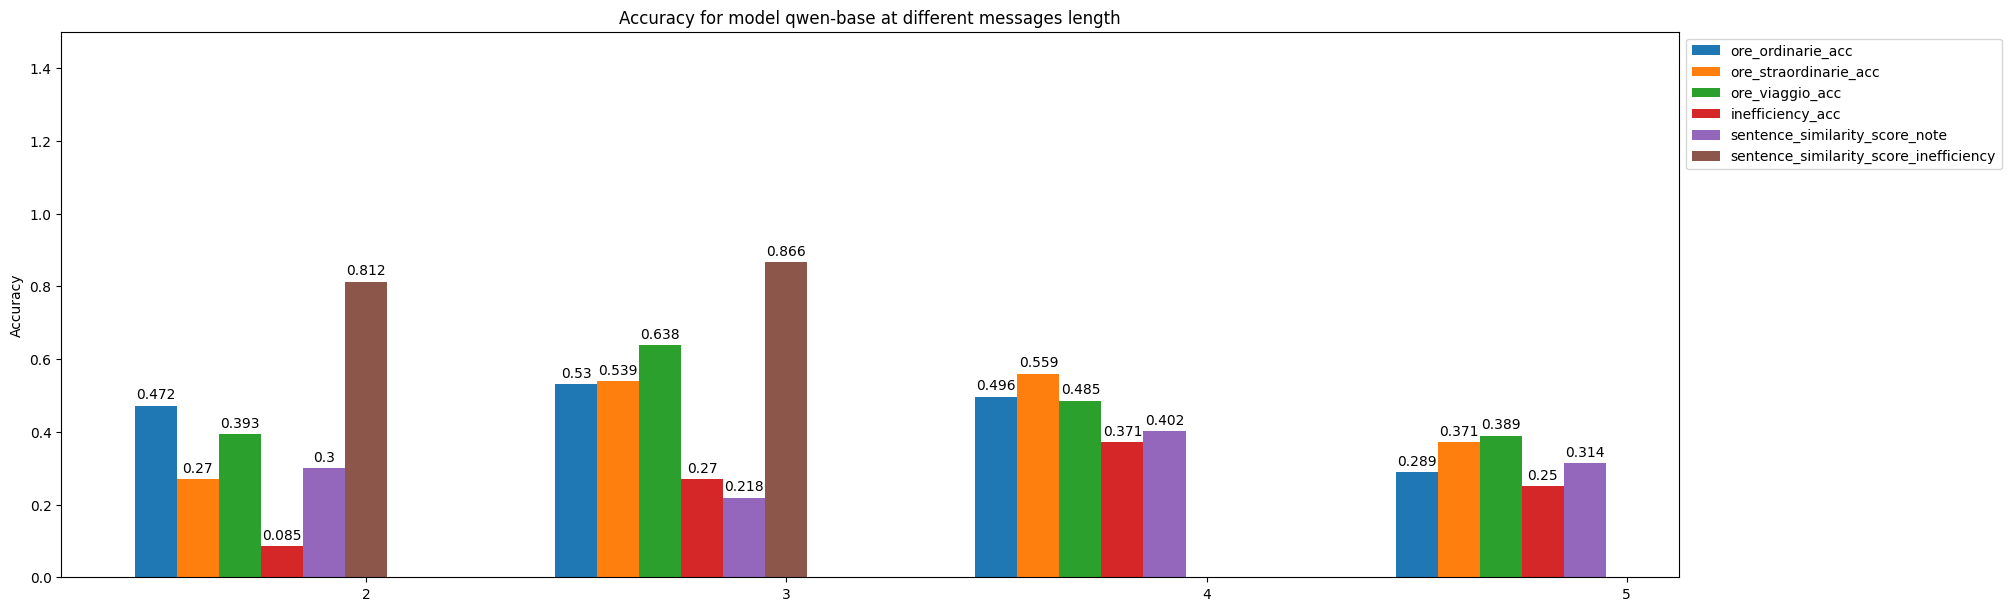

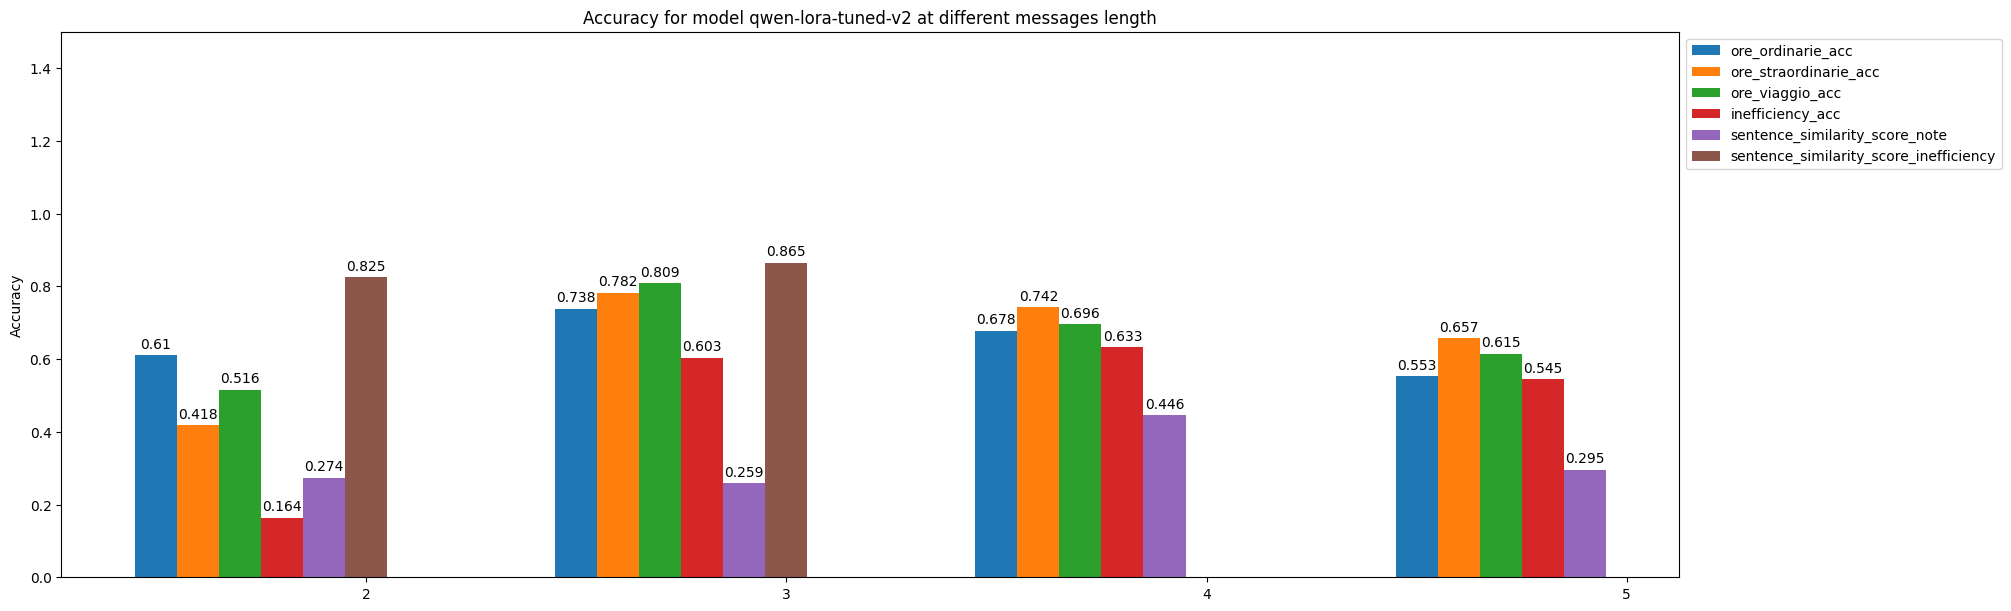

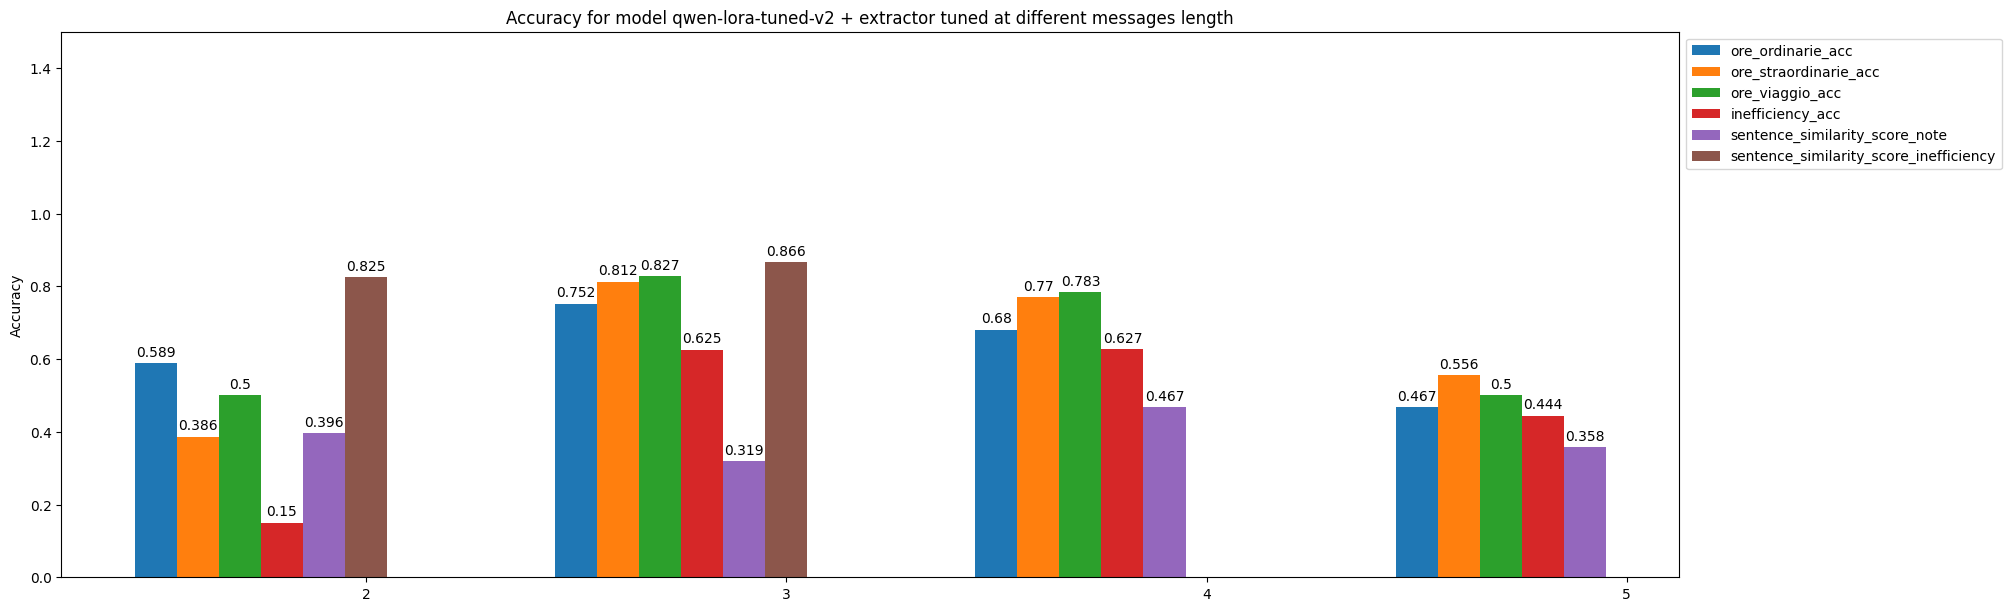

In [ ]:
# chart per fare il display accuracy totale  al variare del flow


l_msg = np.sort(df['L_MESSAGGI'].unique())
for model,label in zip(models,model_labels):
    metric_means = {}
    columns = ['ore_ordinarie_acc', 'ore_straordinarie_acc', 'ore_viaggio_acc','inefficiency_acc','sentence_similarity_score_note','sentence_similarity_score_inefficiency']
    # init il dict
    for column in columns:
        metric_means[column] = ()

    for length_m in l_msg:
        for column in columns:
            if column == 'sentence_similarity_score_inefficiency' or column == 'sentence_similarity_score_note':
                ris = (round(df.loc[(df['model'] == model) & (df[column].isna() != True) & (df['L_MESSAGGI'] == length_m)][column].mean(),3),)
                metric_means[column] += ris
            else:
                ris = (round(df.loc[(df['model'] == model) & (df['L_MESSAGGI'] == length_m)][column].mean(),3),)
                metric_means[column] += ris
    
    x = np.arange(len(l_msg))  # the label locations
    width = 0.10  # the width of the bars
    multiplier = 0
    fig, ax = plt.subplots(figsize=(20,6), layout='constrained')
    for attribute, measurement in metric_means.items():
        offset = width * multiplier
        rects = ax.bar(x + offset, measurement, width, label=attribute)
        ax.bar_label(rects, padding=3)
        
        # inseriamo l'accuracy media
        """ if attribute == 'ore_viaggio_acc':
            x_pos = x + offset
            for x in x_pos:
                ax.text(x, 1.1,'prova') """

        multiplier += 1
    ax.set_ylabel('Accuracy')
    ax.set_title(f'Accuracy for model {label} at different messages length')
    ax.set_xticks(x + offset, l_msg)
    ax.legend(loc="upper left", bbox_to_anchor=(1, 1))
    ax.set_ylim(0, 1.5)

## Failure Analisys

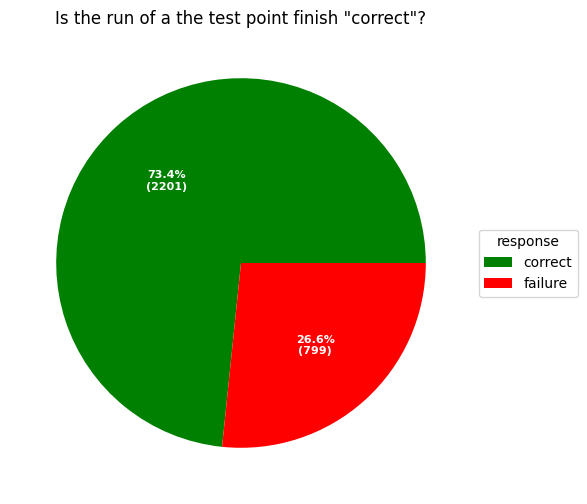

In [17]:
fig, ax = plt.subplots(figsize=(20, 6), subplot_kw=dict(aspect="equal"))

def func(pct,all):
    absolute = int(np.round(pct/100.*np.sum(all)))
    return f"{pct:.1f}%\n({absolute})"

dict_results = {'correct': df['failure_reason'].isna().sum(), 'failure':df['failure_reason'].notna().sum()}
data = dict_results.values()
labels = dict_results.keys()
wedges, texts, autotexts = ax.pie(data, autopct=lambda pct: func(pct,list(data)),colors=['green', 'red'],
                                  textprops=dict(color="w"))

ax.legend(wedges,labels,
          title="response",
          loc="center left",
          bbox_to_anchor=(1, 0, 0.5, 1))

plt.setp(autotexts, size=8, weight="bold")

ax.set_title('Is the run of a the test point finish "correct"?')
plt.show()

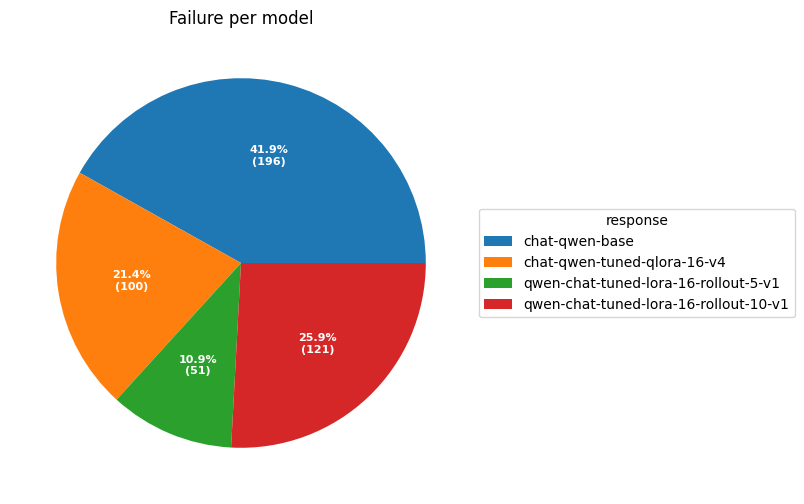

In [54]:
# failure rate per model
fig, ax = plt.subplots(figsize=(20, 6), subplot_kw=dict(aspect="equal"))

def func(pct,all):
    absolute = int(np.round(pct/100.*np.sum(all)))
    return f"{pct:.1f}%\n({absolute})"

dict_results = {}
for model in models:
    dict_results[model] = df.loc[df['model'] == model]['failure_reason'].notna().sum() 

data = dict_results.values()
labels = dict_results.keys()
wedges, texts, autotexts = ax.pie(data, autopct=lambda pct: func(pct,list(data)),
                                  textprops=dict(color="w"))

ax.legend(wedges,labels,
          title="response",
          loc="center left",
          bbox_to_anchor=(1, 0, 0.5, 1))

plt.setp(autotexts, size=8, weight="bold")

ax.set_title('Failure per model')
plt.show()

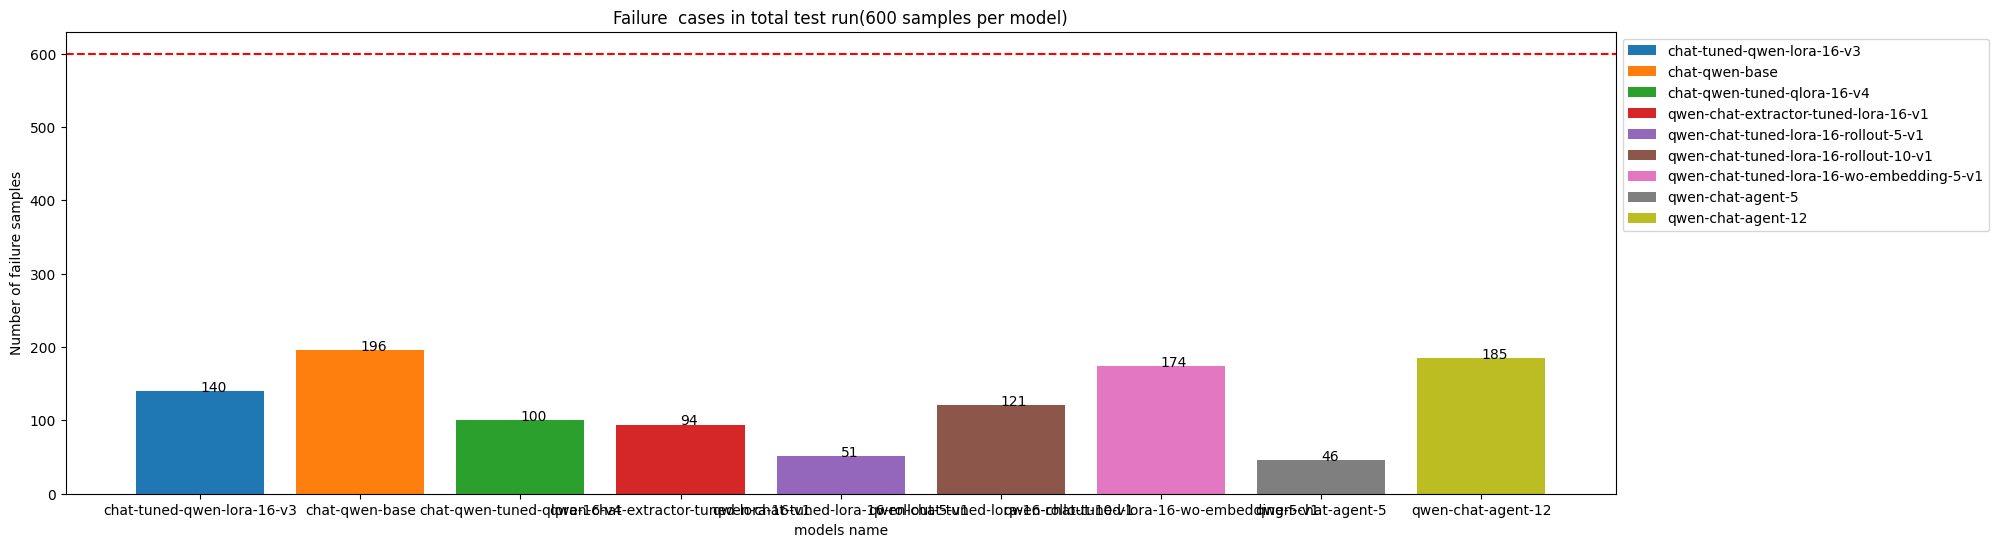

In [16]:
def add_labels(labels, vals):
    for i in range(len(labels)):
        plt.text(i,vals[i], vals[i])

dict_results = {}
for model in models:
    dict_results[model] = df.loc[df['model'] == model]['failure_reason'].notna().sum() 

data = dict_results.values()
labels = dict_results.keys()

plt.figure(figsize=(20,6))
plt.bar(models, data, color=colors, label=models)
add_labels(list(labels),list(data))
plt.axhline(y=len(df.loc[df['model'] == models[0]]), color='red', linestyle='--', linewidth=1.5)
plt.title("Failure  cases in total test run(600 samples per model)")
plt.xlabel("models name")
plt.ylabel("Number of failure samples")
plt.legend(loc="upper left", bbox_to_anchor=(1, 1))

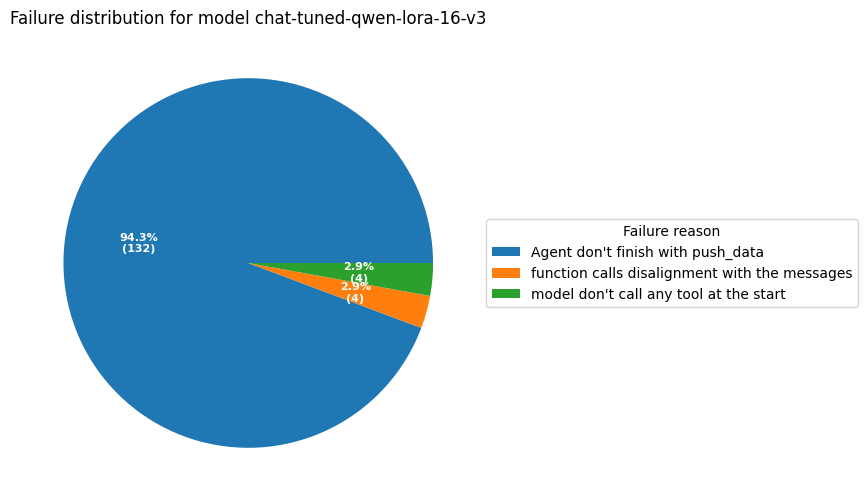

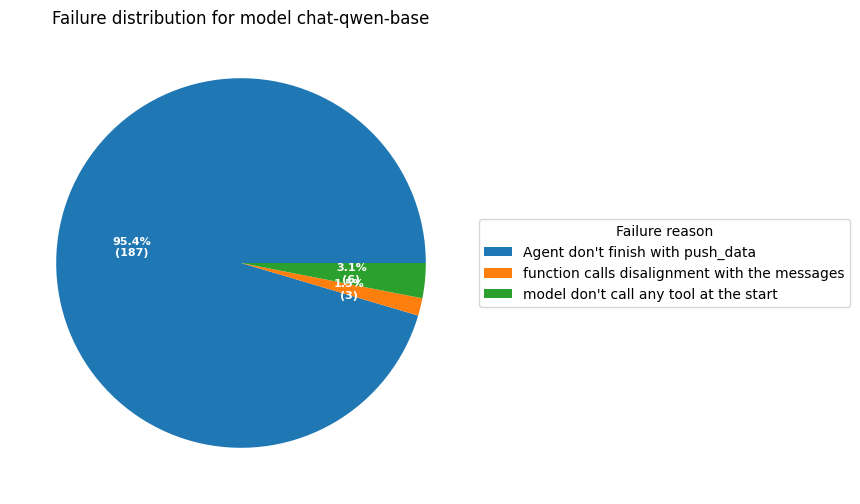

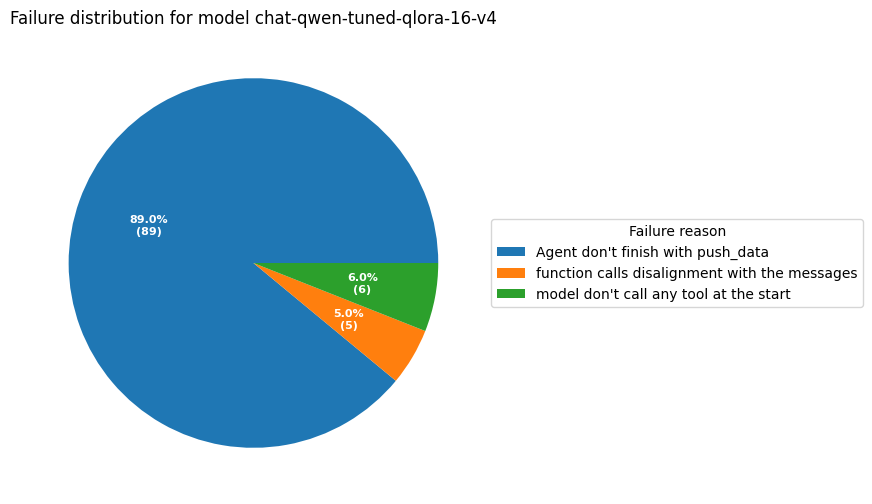

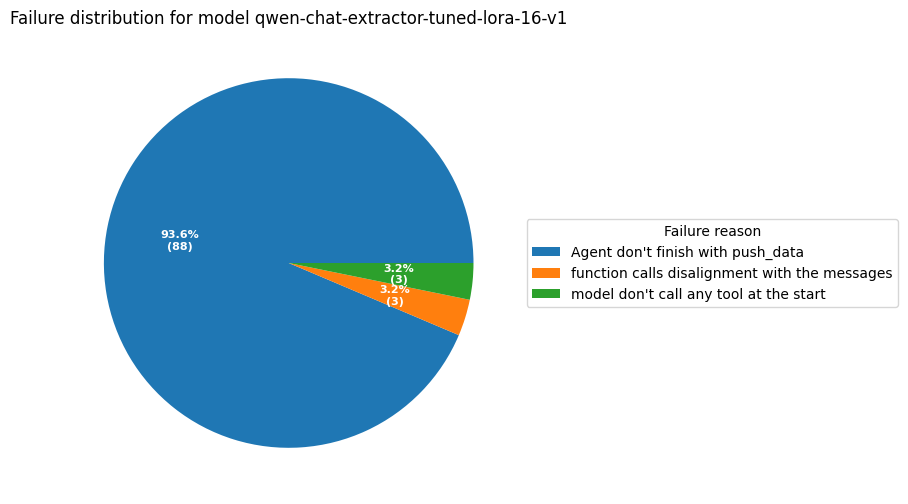

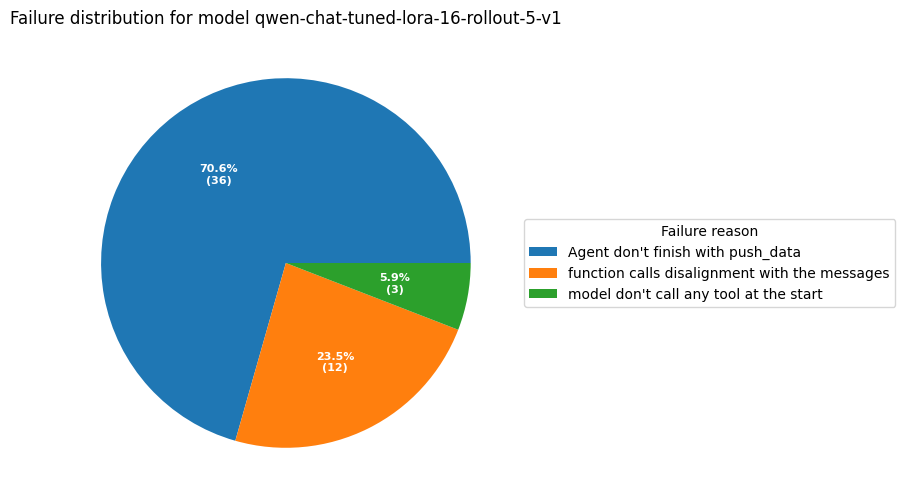

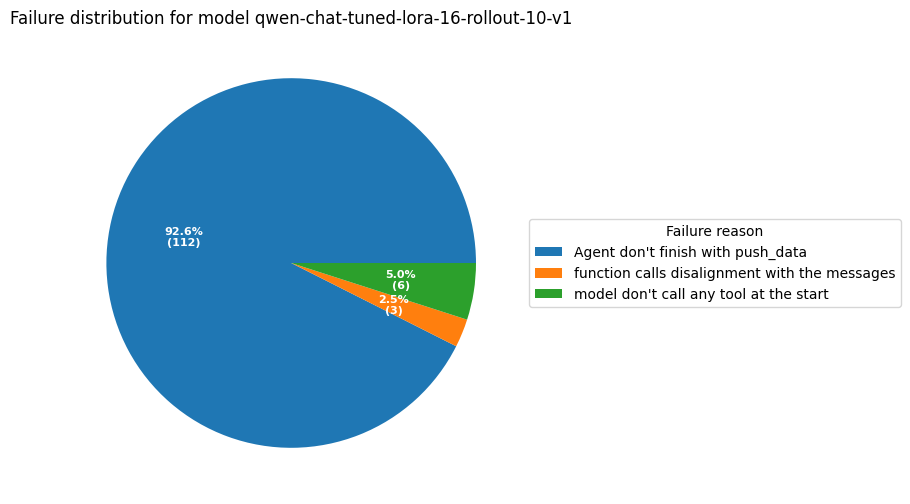

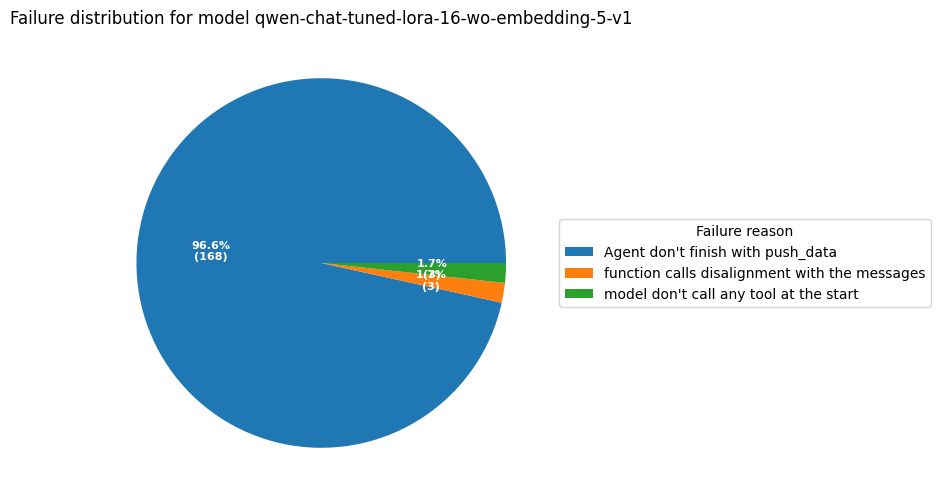

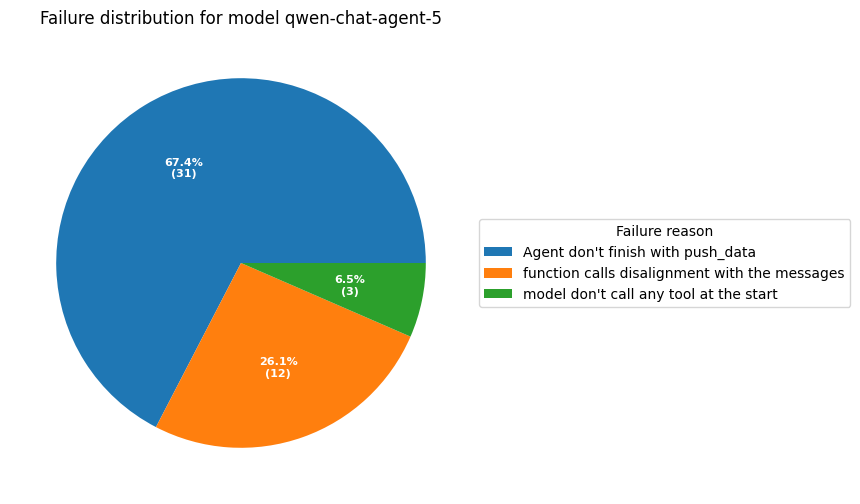

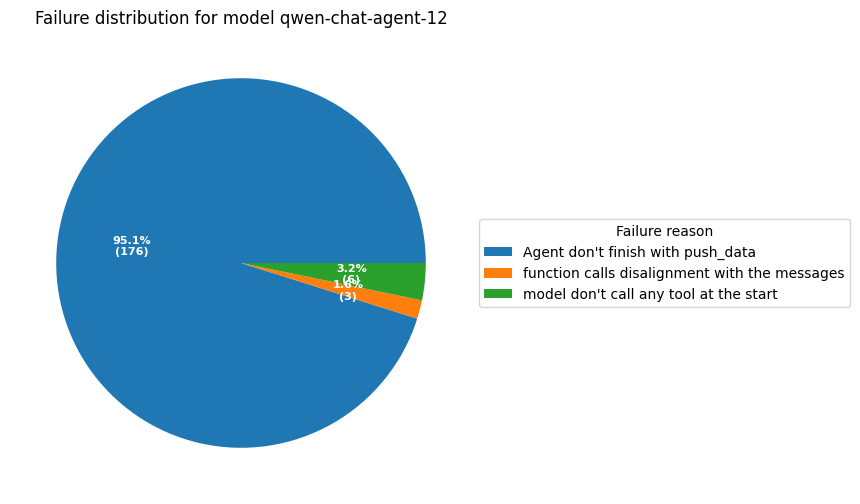

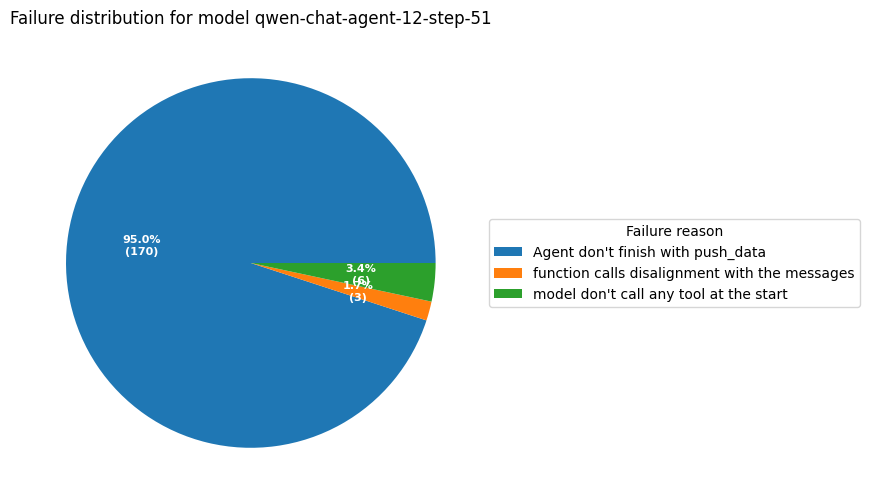

In [13]:
# pei chart sulle tipologie di failure

for model in models:
    fig, ax = plt.subplots(figsize=(20, 6), subplot_kw=dict(aspect="equal"))


    def func(pct,all):
        absolute = int(np.round(pct/100.*np.sum(all)))
        return f"{pct:.1f}%\n({absolute})"

    dict_results = dict(df.loc[df['model'] == model].groupby(['failure_reason'])['REF_INDICE'].count())
    data = dict_results.values()
    labels = dict_results.keys()
    wedges, texts, autotexts = ax.pie(data, autopct=lambda pct: func(pct,list(data)),
                                      textprops=dict(color="w"))

    ax.legend(wedges,labels,
              title="Failure reason",
              loc="center left",
              bbox_to_anchor=(1, 0, 0.5, 1))

    plt.setp(autotexts, size=8, weight="bold")

    ax.set_title(f"Failure distribution for model {model}")
    plt.show()